In [16]:
# INTRODUCTION
'''This project aims to analyze medical insurance costs and identify key factors that influence high healthcare expenses. 
Using regression and classification models, I will aim to predict individual charges and categorize high-risk individuals'''

#DATA CLEANING - (i) loading and previewing data

import pandas as pd
import numpy as np
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
#DATA CLEANING - (ii) checking details of data

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   float64
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   float64
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   bool   
 5   smoker_yes        1337 non-null   bool   
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(4)
memory usage: 58.8 KB


,age,bmi,children,charges
count,1.337000e+03,1337.000000,1.337000e+03,1337.000000
mean,-1.062891e-17,0.000000,6.643070e-18,13279.121487
std,1.000374e+00,1.000374,1.000374e+00,12110.359656
min,-1.511647e+00,-2.411119,-9.092342e-01,1121.873900
25%,-8.705798e-01,-0.717173,-9.092342e-01,4746.344000
50%,-1.582291e-02,-0.043202,-7.944162e-02,9386.161300
75%,8.389340e-01,0.661926,7.503509e-01,16657.717450
max,1.764921e+00,3.684136,3.239729e+00,63770.428010


In [23]:
#DATA CLEANING - (iii) removing duplicates and null

df.isnull().sum() # no missing values found
df.duplicated().sum() # 1 duplicate found
df = df.drop_duplicates()
df.duplicated().sum() # no more duplicates (yay!)

np.int64(0)

In [24]:
#DATA CLEANING - (iv) encoding (categorical variables are being converted into numerical using one-hot encoding)

df = pd.get_dummies(df,drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,16884.92400,False,True,False,False,True
1,-1.511647,0.509422,-0.079442,1725.55230,True,False,False,True,False
2,-0.799350,0.383155,1.580143,4449.46200,True,False,False,True,False
3,-0.443201,-1.305052,-0.909234,21984.47061,True,False,True,False,False
4,-0.514431,-0.292456,-0.909234,3866.85520,True,False,True,False,False


In [27]:
#DATA CLEANING - (v) scaling (numerical features are being standardized using StandardScaler so that they have a mean of 0 and standard dev of 1 to make sure all these feature contribute equally to model training)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['age','bmi', 'children'] # decided not to scale 'charges' column since its a target variable y and not input feature(x)
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,16884.92400,False,True,False,False,True
1,-1.511647,0.509422,-0.079442,1725.55230,True,False,False,True,False
2,-0.799350,0.383155,1.580143,4449.46200,True,False,False,True,False
3,-0.443201,-1.305052,-0.909234,21984.47061,True,False,True,False,False
4,-0.514431,-0.292456,-0.909234,3866.85520,True,False,True,False,False


In [15]:
#-----Data Description----'''

'''The dataset used for this project is the Medical Cost Personal Dataset. 
This dataset has information about individuals and their medical insurance costs.
The dataset has the following variables:

age: Age of the individual (numerical)
sex: Gender of the individual (categorical: male/female)
bmi: Body Mass Index, a measure of body fat based on height and weight (numerical)
children: Number of dependents covered by insurance (numerical, discrete)
smoker: Smoking status (categorical: yes/no)
region: Residential area in the US (categorical: northeast, northwest, southeast, southwest)
charges: Individual medical costs billed by health insurance (numerical, continuous)

The purpose of this project is to perform regression and classification tasks for the medical insurance costs'''


'The dataset used for this project is the Medical Cost Personal Dataset. \nThis dataset has information about individuals and their medical insurance costs.\nThe dataset has the following variables:\n\nage: Age of the individual (numerical)\nsex: Gender of the individual (categorical: male/female)\nbmi: Body Mass Index, a measure of body fat based on height and weight (numerical)\nchildren: Number of dependents covered by insurance (numerical, discrete)\nsmoker: Smoking status (categorical: yes/no)\nregion: Residential area in the US (categorical: northeast, northwest, southeast, southwest)\ncharges: Individual medical costs billed by health insurance (numerical, continuous)\n\nThe purpose of this project is to perform regression and classification tasks for the medical insurance costs'

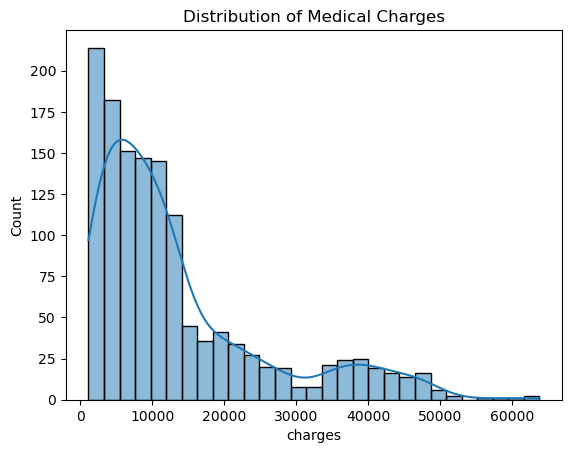

In [30]:
#-----Exploratory Data Analysis----

#Plot 1- Distribution of Charges
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()
# output analysis: distribution of medical charges is right-skewed, which shows that a lot of individuals has lower charges while few incur higher coster


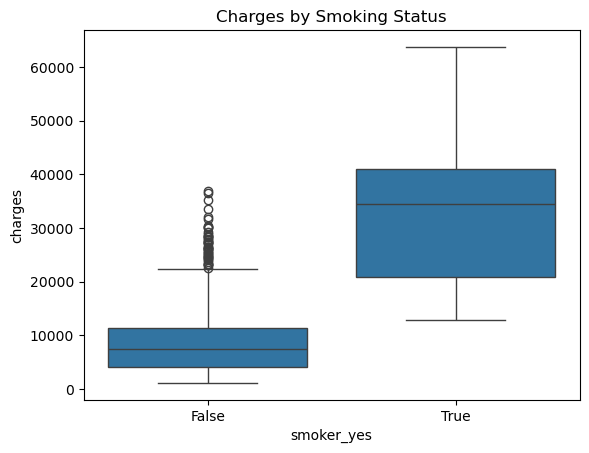

In [31]:
#Plot 2- Charges vs Smoker

sns.boxplot(x='smoker_yes', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()
#output analysis: Smokers contribute significantly to higher medical charges compared to non-smokers

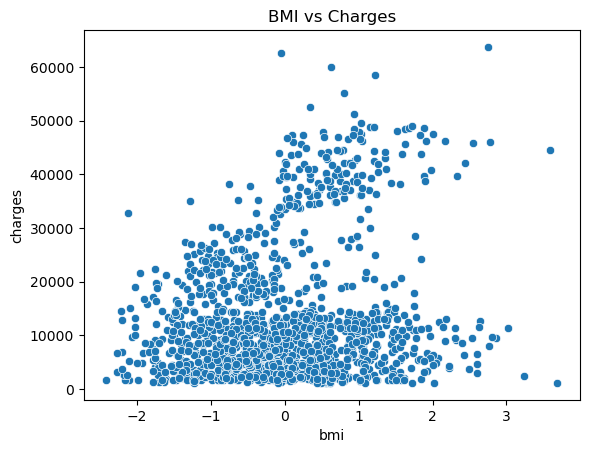

In [32]:
#Plot 3- BMI vs Charges

sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

#output analysis: plot shows a positive relationship between BMI and medical charges which shows that higher BMI leads to increased costs.

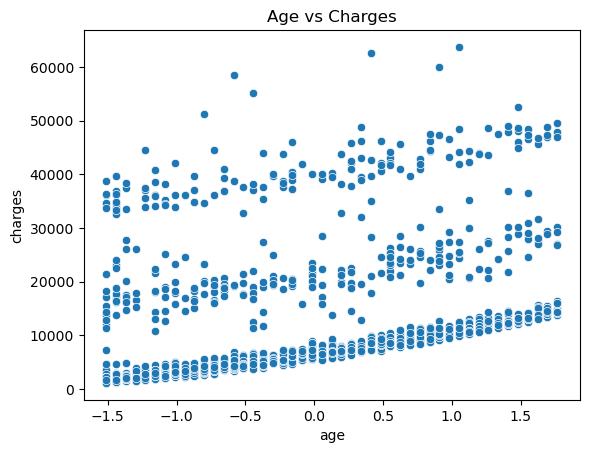

In [33]:
#Plot 4- Age vs Charges

sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

#output analysis: Medical charges tend to increase with age which shows that older people might need more healthcare servicess

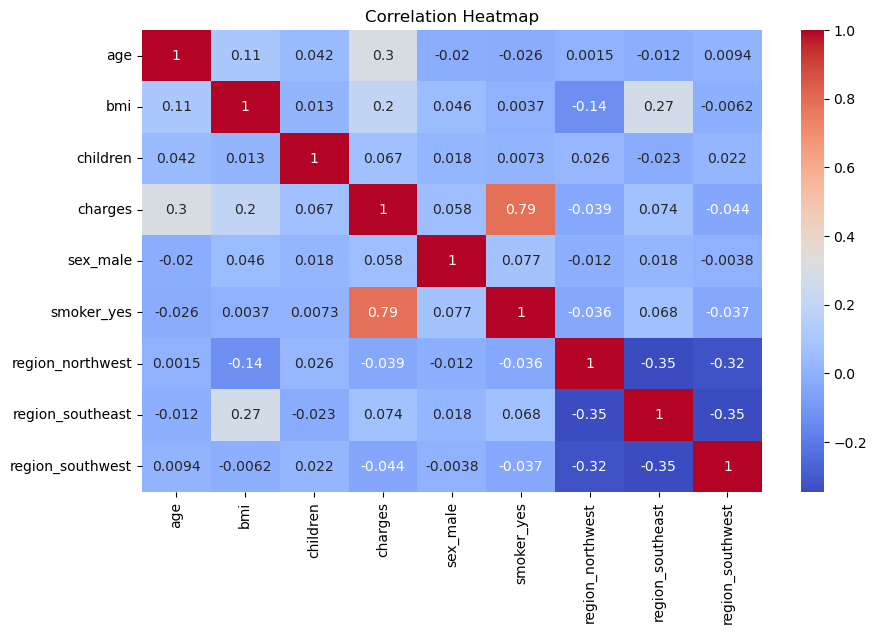

In [34]:
#Plot 5- Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#output analsyis: the heatmap shows significant correlation between smoking and charges, moderate correlation between age and BMI which further confirms previous insights!

In [ ]:
 #-----Feature Engineering----

'''Creating additional features to better capture relationships in the data, for example:

* Categorize BMI into health groups
* Groupe age into ranges
* Creating interaction terms (eg- smoker × BMI)'''



In [ ]:
#-----Modeling----

'''Starting with developing both regression and classification models to perform these tasks:
Regression models to predict the continuous values of insurance charges
Classification models to classify individuals based on high or low insurance charges
*also using regularization methods to control the complexity of the models and assess the bias-variance tradeoff'''

In [ ]:
#-----Evaluation----

'''Using train/test split to evaluate model generalization
Apply cross-validation to compare model performance
Use multiple evaluation metrics:
Regression: RMSE, R²
Classification: Accuracy, ROC-AUC'''

In [ ]:
#-----Results----

In [ ]:
#-----Conclusion----